In [8]:
from langchain_core.documents.base import Blob
from langchain_community.document_loaders import PyPDFLoader
from dotenv import load_dotenv
import os
import json
from typing import TypedDict, List, Dict, Any

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

In [9]:
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")


# ---------------------------
# LLM
# ---------------------------
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=groq_api_key,
    temperature=0
)


In [10]:
class JobfetchState():
    document:any
    resume_json: dict
    path_to_pdf:str
    name:str


In [11]:
def pdf_parse(state: JobfetchState):
    pdf_url=state['path_to_pdf']
    loader = PyPDFLoader(pdf_url)
    docs = loader.load()

    document = "\n".join(page.page_content for page in docs)

    return {
        "document": document
    }

In [12]:
def llm_node(state: JobfetchState):

    prompt = f"""
You are an expert resume parser.

Extract the following information from the resume.

Return ONLY valid JSON.
Do not use markdown.
Do not write explanations.
Do not wrap the JSON in ```.

JSON Schema:

{{
    "name": "",
    "job_title": "",
    "skills": []
}}

Instructions:
- "job_title" should be the candidate's current or most recent role.
- Put ALL technical and professional skills into the single "skills" array.
- Do not create separate categories like programming languages, frameworks, tools, databases, cloud, etc.
- Remove duplicate skills.

Resume:

{state["document"]}
"""

    response = llm.invoke(prompt)
    resume_json = json.loads(response.content)
      # Save using the candidate's name as the filename
    filename = f'{resume_json["name"]}.json'

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(resume_json, f, indent=4, ensure_ascii=False)

    return {
        "resume_json": resume_json,
        "name": resume_json["name"]
    }

In [13]:
graph = StateGraph(JobfetchState)

graph.add_node("pdf_parse", pdf_parse)
graph.add_node("llm_node", llm_node)

graph.set_entry_point("pdf_parse")

graph.add_edge("pdf_parse", "llm_node")
graph.add_edge("llm_node", END)

app = graph.compile()

In [14]:
result = app.invoke({
    "path_to_pdf":"JOBIN JOSE_CV.pdf"
})

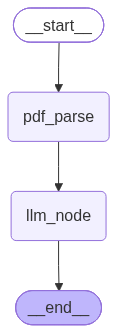

In [16]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)